In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

In [2]:
with open('data_simple_line_perturbed_2D_1000_turns.pkl', 'rb') as f:
    data = pickle.load(f)

In [3]:
data.keys()

dict_keys(['x', 'px'])

In [4]:
data['x'].shape, data['px'].shape

((1600, 1001), (1600, 1001))

Text(0, 0.5, '$p_x$')

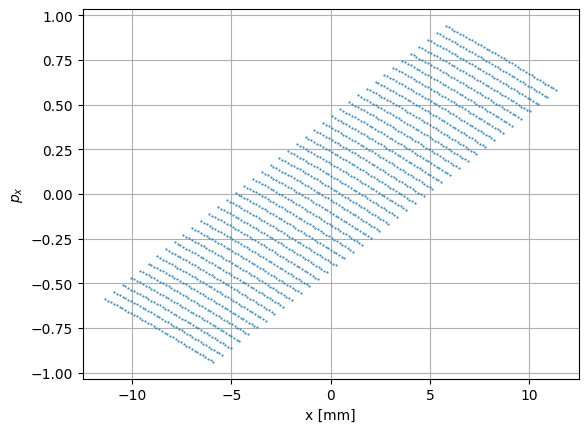

In [5]:
plt.plot(data['x'][:, 100] * 1000, data['px'][:, 1000] * 100, '.', markersize=1, color='C0')
plt.grid()
plt.xlabel('x [mm]')
plt.ylabel(r'$p_x$')

In [6]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from models import GSympNet

In [7]:
# Hyperparameters
dim = 2
layers = 3
width = 20
activation = torch.sigmoid
epochs = 10000
batch_size = 64
learning_rate = 1e-3

In [8]:
# # x_xp_data_list = [np.array([data['x'][i, :], data['px'][i, :]]).T for i in range(data['x'].shape[0])]
# x_xp_data_list = [np.array([data['x'][i, :], data['px'][i, :]]).T for i in range(700)]
# x_xp_data = np.vstack(x_xp_data_list)

In [9]:
def min_max_normalize(arr, min_val=None, max_val=None):
    """
    Min-max normalize a numpy array or torch tensor of shape (N, 2) to range [-1, 1].
    If min_val and max_val are not provided, compute from arr along axis=0.
    Returns normalized array, min_val, and max_val.
    """
    if min_val is None:
        min_val = arr.min(axis=0, keepdims=True)
    if max_val is None:
        max_val = arr.max(axis=0, keepdims=True)
    normalized = 2 * (arr - min_val) / (max_val - min_val) - 1
    return normalized, min_val, max_val

def min_max_denormalize(arr, min_val, max_val):
    """
    Denormalize a numpy array or torch tensor of shape (N, 2) from range [-1, 1]
    back to the original range defined by min_val and max_val.
    """
    return (arr + 1) / 2 * (max_val - min_val) + min_val

In [10]:
index = 0
x_xp_data = np.array([data['x'][index, :], data['px'][index, :]]).T

In [11]:
x_xp_data.shape, x_xp_data.dtype

((1001, 2), dtype('float64'))

In [12]:
x_xp_data_norm, min, max = min_max_normalize(x_xp_data)

In [13]:
input, output = x_xp_data_norm[:-1], x_xp_data_norm[1:]

In [14]:
input-output

array([[-0.87911808, -1.49370355],
       [-0.61498224,  1.76292315],
       [ 1.68373775, -0.83112678],
       ...,
       [-1.79638432,  0.518149  ],
       [ 1.44190263,  0.97977162],
       [-0.09066488, -1.80479659]], shape=(1000, 2))

In [15]:
train_x = torch.tensor(input, dtype=torch.float32)
train_y = torch.tensor(output, dtype=torch.float32)

In [16]:
train_x.shape

torch.Size([1000, 2])

In [17]:
dataset = TensorDataset(train_x, train_y)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [18]:
model = GSympNet(dim, layers, width, activation)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = torch.nn.MSELoss()

In [19]:
model.train()
for epoch in range(epochs):
    total_loss = 0.0
    for x_batch, y_batch in loader:
        optimizer.zero_grad()
        pred = model(x_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x_batch.size(0)
    avg_loss = total_loss / len(dataset)    
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.10f}")

Epoch 1/10000, Loss: 1.6578840265
Epoch 2/10000, Loss: 1.6578655386
Epoch 3/10000, Loss: 1.6578747034
Epoch 4/10000, Loss: 1.6578588781
Epoch 5/10000, Loss: 1.6578582773
Epoch 6/10000, Loss: 1.6578583393
Epoch 7/10000, Loss: 1.6578589716
Epoch 8/10000, Loss: 1.6578619404
Epoch 9/10000, Loss: 1.6578652134
Epoch 10/10000, Loss: 1.6578565760
Epoch 11/10000, Loss: 1.6578569813
Epoch 12/10000, Loss: 1.6578543005
Epoch 13/10000, Loss: 1.6578589411
Epoch 14/10000, Loss: 1.6578552313
Epoch 15/10000, Loss: 1.6578567600
Epoch 16/10000, Loss: 1.6578541727
Epoch 17/10000, Loss: 1.6578527470
Epoch 18/10000, Loss: 1.6578543701
Epoch 19/10000, Loss: 1.6578541718
Epoch 20/10000, Loss: 1.6578520517
Epoch 21/10000, Loss: 1.6578522053
Epoch 22/10000, Loss: 1.6578579578
Epoch 23/10000, Loss: 1.6578492832
Epoch 24/10000, Loss: 1.6578598413
Epoch 25/10000, Loss: 1.6578513880
Epoch 26/10000, Loss: 1.6578467102
Epoch 27/10000, Loss: 1.6578491898
Epoch 28/10000, Loss: 1.6578421860
Epoch 29/10000, Loss: 1.65785

In [49]:
torch.save(model.state_dict(),'sympnet_model_particle1.pt')

In [29]:
# Re-instantiate the model and load the saved weights
model = GSympNet(dim, layers, width, activation)
model.load_state_dict(torch.load('sympnet_model_particle1.pt'))

<All keys matched successfully>

In [30]:
x_xp_init_test = np.array([data['x'][index, 0], data['px'][index, 0]]).T

In [31]:
x_xp_init_test = x_xp_init_test.reshape(1, 2)
x_xp_init_test.shape, x_xp_init_test.dtype

((1, 2), dtype('float64'))

In [32]:
min.dtype

dtype('float64')

In [33]:
x_xp_init_test_norm = min_max_normalize(x_xp_init_test, min, max)[0]

In [34]:
x_xp_init_test_tensor = torch.tensor(x_xp_init_test_norm, dtype=torch.float32)

In [35]:
# x_xp_init_test_tensor = x_xp_init_test_tensor.unsqueeze(0)  # Add batch dimension
x_xp_init_test_tensor.shape

torch.Size([1, 2])

In [36]:
pred_init = model.predict(x_xp_init_test_tensor, steps=1000)

In [37]:
train_y.shape

torch.Size([1000, 2])

Text(0, 0.5, '$p_x$')

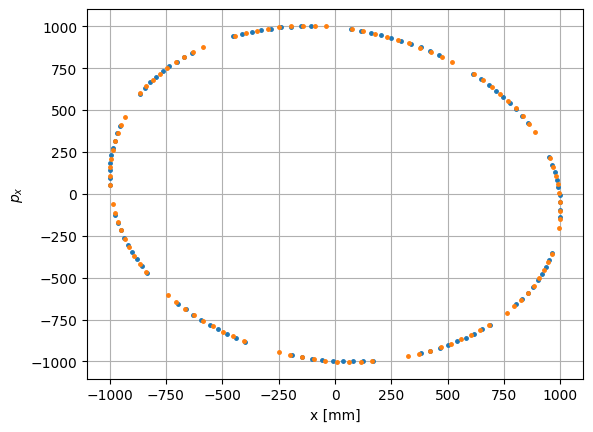

In [38]:
plt.plot(train_y[:100, 0].detach().numpy() * 1000, train_y[:100, 1].detach().numpy() * 1000, '.', markersize=5, color='C0')
plt.plot(pred_init[:, :100, 0].detach().numpy() * 1000, pred_init[:, :100, 1].detach().numpy() * 1000, '.', markersize=5, color='C1')
plt.grid()
plt.xlabel('x [mm]')
plt.ylabel(r'$p_x$')

In [40]:
pred = min_max_denormalize(pred_init.detach().numpy(), min, max)

In [41]:
pred

array([[[ 0.00094561,  0.00958689],
        [ 0.0085223 , -0.00763431],
        [-0.01233791,  0.00051452],
        ...,
        [ 0.01126933, -0.00490641],
        [-0.01128181, -0.00313096],
        [ 0.00349578,  0.00897235]]], shape=(1, 1000, 2))

In [42]:
act = x_xp_data[1:]

Text(0, 0.5, '$p_x$')

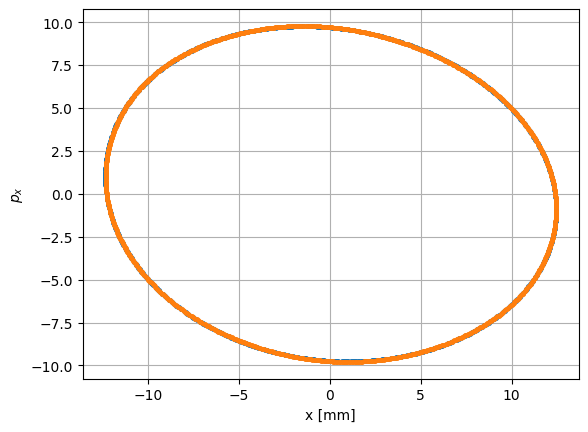

In [43]:
plt.plot(act[:, 0] * 1000, act[:, 1] * 1000, '.', markersize=5, color='C0')
plt.plot(pred[:, :, 0] * 1000, pred[:, :, 1] * 1000, '.', markersize=5, color='C1')
plt.grid()
plt.xlabel('x [mm]')
plt.ylabel(r'$p_x$')

In [53]:
act[:10,0].shape, pred[:, :10, 1].squeeze().shape

((10,), (10,))

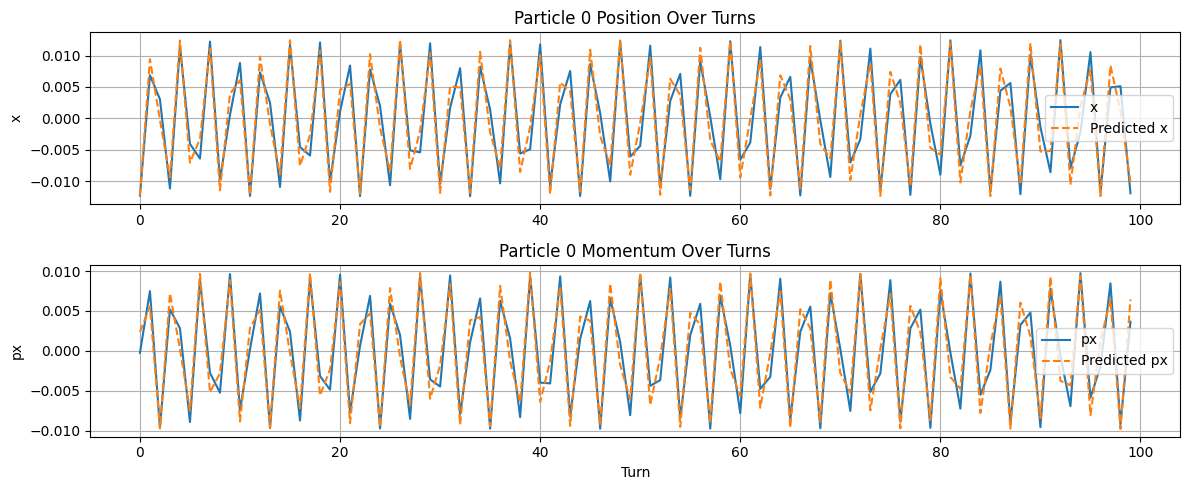

In [ ]:
# Plot position and momentum over turns
plt.figure(figsize=(12, 5))
plt.subplot(2, 1, 1)
plt.plot(act[400:500, 0], label='x', color='C0')
plt.plot(pred[:, 400:500, 0].squeeze(), label='Predicted x', linestyle='--', color='C1')
plt.title(f'Particle {index} Position Over Turns')
plt.ylabel('x')
plt.grid()
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(act[400:500, 1], label='px', color='C0')
plt.plot(pred[:, 400:500, 1].squeeze(), label='Predicted px', linestyle='--', color='C1')
plt.title(f'Particle {index} Momentum Over Turns')
plt.xlabel('Turn')
plt.ylabel('px')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

Text(0, 0.5, '$p_x$')

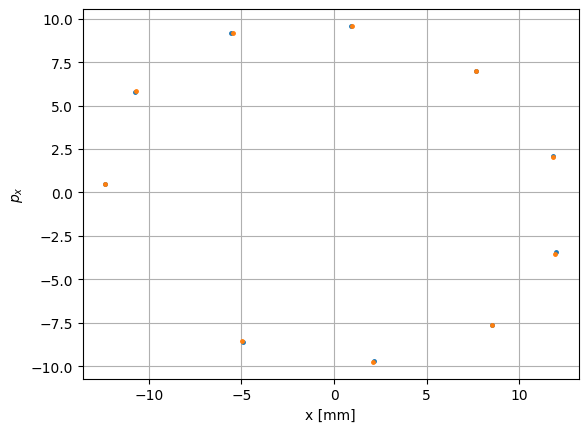

In [56]:
plt.plot(act[:10, 0] * 1000, act[:10, 1] * 1000, '.', markersize=5, color='C0')
plt.plot(pred[:, :10, 0] * 1000, pred[:, :10, 1] * 1000, '.', markersize=5, color='C1')
plt.grid()
plt.xlabel('x [mm]')
plt.ylabel(r'$p_x$')

prediction on different particle

In [60]:
index = 550

In [61]:
x_xp_init_test = np.array([data['x'][index, 0], data['px'][index, 0]]).T

In [62]:
x_xp_init_test = x_xp_init_test.reshape(1, 2)
x_xp_init_test.shape, x_xp_init_test.dtype

((1, 2), dtype('float64'))

In [63]:
min.dtype

dtype('float64')

In [64]:
x_xp_init_test_norm = min_max_normalize(x_xp_init_test, min, max)[0]

In [65]:
x_xp_init_test_tensor = torch.tensor(x_xp_init_test_norm, dtype=torch.float32)

In [66]:
# x_xp_init_test_tensor = x_xp_init_test_tensor.unsqueeze(0)  # Add batch dimension
x_xp_init_test_tensor.shape

torch.Size([1, 2])

In [67]:
pred_init = model.predict(x_xp_init_test_tensor, steps=1000)

In [68]:
pred = min_max_denormalize(pred_init.detach().numpy(), min, max)

In [69]:
x_xp_data_act = np.array([data['x'][index, :], data['px'][index, :]]).T
# x_xp_data.shape, x_xp_data.dtype
act = x_xp_data_act[1:]

In [70]:
act

array([[-0.0047433 , -0.00198464],
       [ 0.00083531,  0.00427247],
       [ 0.00359172, -0.00364223],
       ...,
       [-0.00430975,  0.00317211],
       [ 0.00555798,  0.00023725],
       [-0.00301974, -0.00348506]], shape=(1000, 2))

In [71]:
pred_init

tensor([[[-0.3828, -0.2035],
         [ 0.0588,  0.4341],
         [ 0.2898, -0.3642],
         ...,
         [-0.4512,  0.0189],
         [ 0.2718,  0.3268],
         [ 0.0849, -0.4454]]], grad_fn=<ViewBackward0>)

In [72]:
pred = min_max_denormalize(pred_init.detach().numpy(), min, max)

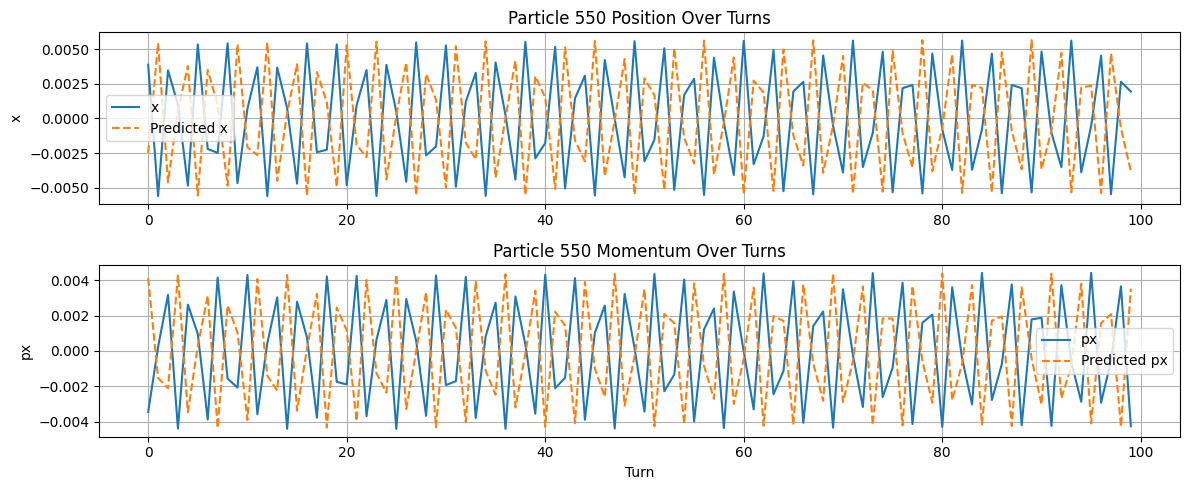

In [73]:
# Plot position and momentum over turns
plt.figure(figsize=(12, 5))
plt.subplot(2, 1, 1)
plt.plot(act[400:500, 0], label='x', color='C0')
plt.plot(pred[:, 400:500, 0].squeeze(), label='Predicted x', linestyle='--', color='C1')
plt.title(f'Particle {index} Position Over Turns')
plt.ylabel('x')
plt.grid()
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(act[400:500, 1], label='px', color='C0')
plt.plot(pred[:, 400:500, 1].squeeze(), label='Predicted px', linestyle='--', color='C1')
plt.title(f'Particle {index} Momentum Over Turns')
plt.xlabel('Turn')
plt.ylabel('px')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [113]:
pred.shape

(1, 1000, 2)

Multiple particles

In [119]:
x_xp_init_test = np.array([data['x'][500:1000, 0], data['px'][500:1000, 0]]).T

In [120]:
# x_xp_init_test = x_xp_init_test.reshape(1, 2)
x_xp_init_test.shape, x_xp_init_test.dtype

((500, 2), dtype('float64'))

In [121]:
x_xp_init_test_norm = min_max_normalize(x_xp_init_test, min, max)[0]

In [122]:
x_xp_init_test_tensor = torch.tensor(x_xp_init_test_norm, dtype=torch.float32)

In [123]:
# x_xp_init_test_tensor = x_xp_init_test_tensor.unsqueeze(0)  # Add batch dimension
x_xp_init_test_tensor.shape

torch.Size([500, 2])

In [124]:
pred_init = model.predict(x_xp_init_test_tensor, steps=1000)

In [125]:
pred = min_max_denormalize(pred_init.detach().numpy(), min, max)

In [126]:
x_xp_data_act = np.array([data['x'][500:1000, :], data['px'][500:1000, :]]).T
# x_xp_data.shape, x_xp_data.dtype
act = x_xp_data_act[1:]

In [127]:
act.shape

(1000, 500, 2)

In [128]:
pred_init.shape

torch.Size([500, 1000, 2])

In [129]:
pred = min_max_denormalize(pred_init.detach().numpy(), min, max)

In [130]:
time_step = 100

Text(0, 0.5, '$p_x$')

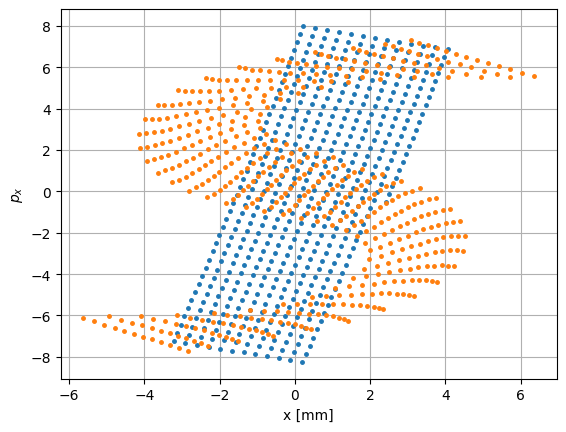

In [131]:
plt.plot(act[time_step, :, 0] * 1000, act[time_step, :, 1] * 1000, '.', markersize=5, color='C0')
plt.plot(pred[:, time_step, 0] * 1000, pred[:, time_step, 1] * 1000, '.', markersize=5, color='C1')
plt.grid()
plt.xlabel('x [mm]')
plt.ylabel(r'$p_x$')